BASE SINIESTROS

In [1]:
import re
import pandas as pd
import requests
from io import StringIO

def extract_drive_id(url_or_id: str) -> str:
    """
    Acepta un file_id directo o una URL de Drive y devuelve el file_id.
    Soporta:
      - https://drive.google.com/file/d/<ID>/view?usp=sharing
      - https://drive.google.com/open?id=<ID>
      - <ID> directo
    """
    s = url_or_id.strip()

    # Si parece un ID ya (sin http ni /)
    if "http" not in s and "/" not in s and len(s) > 20:
        return s

    # /file/d/<ID>/...
    m = re.search(r"/file/d/([a-zA-Z0-9_-]+)", s)
    if m:
        return m.group(1)

    # open?id=<ID>
    m = re.search(r"[?&]id=([a-zA-Z0-9_-]+)", s)
    if m:
        return m.group(1)

    raise ValueError("No pude extraer el file_id. Pegá un link de archivo de Drive válido o el ID directamente.")

def read_gdrive_csv(url_or_id: str, sep_guess=","):
    file_id = extract_drive_id(url_or_id)
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    resp = requests.get(download_url)
    resp.raise_for_status()
    head = resp.text[:600].lower()

    # Si Drive devolvió HTML (confirmación/permisos), avisamos
    if "<html" in head and "drive" in head:
        raise RuntimeError(
            "Google Drive devolvió HTML (posible verificación o permisos). "
            "Asegurate de que el archivo esté compartido con 'Cualquiera con el enlace (lector)'."
        )

    # Intento con autodetección y fallback de separador
    try:
        return pd.read_csv(StringIO(resp.text), sep=None, engine="python", encoding="utf-8")
    except Exception:
        try:
            return pd.read_csv(StringIO(resp.text), sep=sep_guess, encoding="utf-8")
        except Exception:
            return pd.read_csv(StringIO(resp.text), sep=";", encoding="latin-1")

# 👉 Pegá acá la URL del archivo (NO la de la carpeta)
url_del_archivo = "https://drive.google.com/file/d/1Ds9zXog-lPKlxFIopsBlWhLC45MUVX7o/view?usp=sharing"

Base_Siniestros = read_gdrive_csv(url_del_archivo)
print(Base_Siniestros.head(), Base_Siniestros.shape)

      siniestro     fec_ocu    poliza  item  endoso  tipo_stro  estado  \
0  60072907-2-1  2012-05-14  4-283519     1       1          0       0   
1  60080866-2-2  2012-07-01  4-340741     1       1          0       0   
2  60087362-1-2  2012-08-06  4-400748     1       1          0       0   
3  60087362-3-1  2012-08-06  4-400748     1       1          0       0   
4  60087636-2-2  2012-08-07  4-364604     1       2          0       0   

      pag_CASCO  pag_RC  pag_RCL  ...  inc_RT  inc_RP  inc_DT  inc_DP  inc_IT  \
0    129.712669     0.0        0  ...       0       0       0       0       0   
1   1445.193675     0.0        0  ...       0       0       0       0       0   
2  17751.260385     0.0        0  ...       0       0       0       0       0   
3    437.937477     0.0        0  ...       0       0       0       0       0   
4    122.577137     0.0        0  ...       0       0       0       0       0   

   inc_IP  inc_CR  inc_Otros     Inc_Pesos  Cobertura  
0       0   

In [2]:
Base_Siniestros['inc_CASCO'].unique()

array([  129.71266902,  1445.19367509, 17751.26038544, ...,
        8416.4171115 , -2035.5453993 , 17929.33714094])

BASE EMISION

In [3]:
pip install gdown pandas

In [4]:
import gdown
from pathlib import Path
import pandas as pd

# URL o solo el ID del archivo
url_or_id = "https://drive.google.com/file/d/1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw/view?usp=sharing"
dest = Path("data/archivo.csv")
dest.parent.mkdir(parents=True, exist_ok=True)

# gdown maneja la confirmación de archivos grandes
gdown.download(url=url_or_id, output=str(dest), quiet=False, fuzzy=True)

# Lectura por chunks para no agotar RAM (ajustá el chunksize a tu PC)
chunks = pd.read_csv(dest, sep=";", encoding="utf-8", chunksize=200_000)
# Ejemplo: conteo de filas sin cargar todo
total_rows = 0
for chunk in chunks:
    total_rows += len(chunk)
print("Filas totales:", total_rows)


import pandas as pd
from pathlib import Path

dest = Path("data/archivo.csv")

Base_Emision = pd.read_csv(dest, sep=";", encoding="utf-8")
print(Base_Emision.head())


Downloading...
From (original): https://drive.google.com/uc?id=1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw
From (redirected): https://drive.google.com/uc?id=1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw&confirm=t&uuid=b48757dc-066e-4102-90db-f77c637e9d0c
To: c:\Users\d78157\Desktop\data\archivo.csv
100%|██████████| 1.66G/1.66G [04:50<00:00, 5.72MB/s]


Filas totales: 5188042
     Idcol     poliza  CD_item  ENDOSO  TIPO ENDOSO   FECHA_EMI     INI_VIG  \
0  5186991  4-1526667        1       1        99999  2018-04-25  2018-04-25   
1  5186992   4-366387        1       1        99999  2012-04-20  2012-04-20   
2  5186993  4-1647694        1       1        99999  2019-01-23  2019-01-23   
3  5186994   4-208091        1       1        99999  2011-11-26  2011-11-26   
4  5186995  4-1647694        1       2        99999  2019-03-22  2019-03-22   

      FIN_VIG   SUMASEG  SUMASEG_ACC  ...  VAR_15  VAR_16  VAR_17  VAR_18  \
0  2018-04-26  127600.0          0.0  ...       1       3       1       1   
1  2012-04-21       0.0          0.0  ...       2      18       1       9   
2  2019-01-24  770000.0          0.0  ...       1      17       1       1   
3  2011-11-27  138000.0          0.0  ...     999     999     999     999   
4  2019-03-23  770000.0          0.0  ...       1      17       1       1   

   VAR_19  VAR_20  Exp_Rc_365  Exp_Casc

In [60]:
#Base_Emision['Exp_Casco_365'].min()
Base_Emision['Exp_Rc_365'].unique()
#Base_Emision[Base_Emision['Exp_Casco_365'] > 1]

array([0.01  , 0.3342, 0.337 , 0.3315, 0.2384, 0.1644, 0.2466, 0.2438,
       0.0849, 0.0274, 0.1973, 0.0027, 0.1671, 0.2411, 0.3288, 0.0164,
       0.2904, 0.3096, 0.2521, 0.1342, 0.2959, 0.0795, 0.0822, 0.2137,
       0.0658, 0.2795, 0.2493, 0.2877, 0.0192, 0.0767, 0.0521, 0.0219,
       0.326 , 0.1534, 0.274 , 0.1616, 0.3205, 0.1836, 0.2712, 0.0603,
       0.2548, 0.2822, 0.2329, 0.0438, 0.011 , 0.1507, 0.2027, 0.2658,
       0.1096, 0.0685, 0.1562, 0.2575, 0.1068, 0.    , 0.2274, 0.3041,
       0.0137, 0.0932, 0.0548, 0.3233, 0.0904, 0.137 , 0.2   , 0.1315,
       0.5041, 0.4959, 0.3014, 0.3178, 0.1151, 0.1425, 0.0301, 1.    ,
       0.0466, 0.0082, 0.1452, 0.126 , 0.2164, 0.4384, 0.3123, 0.263 ,
       0.2247, 0.4658, 0.1041, 0.0247, 0.2356, 0.1699, 0.2192, 0.1589,
       0.0055, 0.0356, 0.1397, 0.3068, 0.2849, 0.0877, 0.1123, 0.0986,
       0.1753, 0.1479, 0.1205, 0.0329, 0.2055, 0.1918, 0.2603, 0.074 ,
       0.1288, 0.063 , 0.189 , 0.0575, 0.1781, 0.0411, 0.1178, 0.1945,
      

TRABAJO CON AMBAS TABLAS

In [61]:
Base_Siniestros["poliza"] = Base_Siniestros["poliza"].astype(str).str.strip()
Base_Siniestros["item"]   = Base_Siniestros["item"].astype(str).str.strip()


In [62]:
Base_Emision["poliza"]   = Base_Emision["poliza"].astype(str).str.strip()
Base_Emision["CD_item"]  = Base_Emision["CD_item"].astype(str).str.strip()

In [63]:
# 2) Crear clave compuesta en ambos
Base_Siniestros["key"] = Base_Siniestros["poliza"] + "|" + Base_Siniestros["item"]
Base_Emision["key"]    = Base_Emision["poliza"] + "|" + Base_Emision["CD_item"]

In [64]:
# 3) Conjunto de claves disponibles en emisión (únicas)
keys_emision = set(Base_Emision["key"].dropna().unique())

In [65]:
# 4) Flag 1/0 según exista en emisión
Base_Siniestros["flag_emision"] = Base_Siniestros["key"].isin(keys_emision).astype(int)

In [66]:
# Chequeos rápidos
print(Base_Siniestros["flag_emision"].value_counts(dropna=False))

1    310904
0       271
Name: flag_emision, dtype: int64


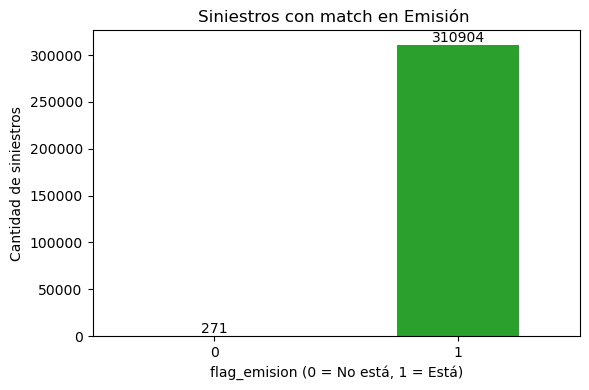

In [ ]:
import matplotlib.pyplot as plt

conteo = Base_Siniestros["flag_emision"].value_counts(dropna=False).sort_index()

ax = conteo.plot(kind="bar", color=["#d62728", "#2ca02c"], figsize=(6,4))
ax.set_title("Siniestros con match en Emisión ")
ax.set_xlabel("flag_emision (0 = No está, 1 = Está)")
ax.set_ylabel("Cantidad de siniestros")
ax.bar_label(ax.containers[0], fmt="%.0f")

plt.xticks(rotation=0)
plt.tight_layout()